In [1]:
import pandas as pd 

In [2]:
df=pd.read_csv("diabetes_risk.csv")
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [4]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

In [5]:
df.shape

(15000, 19)

In [8]:
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [9]:
df['diabetes_risk'].value_counts()

diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64

In [10]:
df['diabetes_risk'].value_counts(normalize=True)

diabetes_risk
Low         0.60
Moderate    0.25
High        0.15
Name: proportion, dtype: float64

In [11]:
df.groupby("diabetes_risk")['bmi'].mean()

diabetes_risk
High        25.108533
Low         22.133200
Moderate    24.064240
Name: bmi, dtype: float64

In [13]:
df.groupby("diabetes_risk")['fasting_blood_sugar'].mean()

diabetes_risk
High        226.540444
Low         148.299444
Moderate    183.316800
Name: fasting_blood_sugar, dtype: float64

In [14]:
df.groupby("diabetes_risk")['age'].mean()

diabetes_risk
High        49.169333
Low         41.872222
Moderate    47.339733
Name: age, dtype: float64

In [16]:
df.groupby('diabetes_risk')[['bmi','fasting_blood_sugar','age']].mean()

,bmi,fasting_blood_sugar,age
diabetes_risk,,,
High,25.108533,226.540444,49.169333
Low,22.133200,148.299444,41.872222
Moderate,24.064240,183.316800,47.339733


In [17]:
risk_num={'Low':0,'Moderate':1, 'High':2}
df['risk_score']=df['diabetes_risk'].map(risk_num)

df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,risk_score
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low,0
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low,0
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High,2
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low,0
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low,0


In [19]:
numeric_df=df.select_dtypes(include="number")

corr=numeric_df.corr()

corr['risk_score'].sort_values(ascending=False)

risk_score                  1.000000
fasting_blood_sugar         0.738251
hba1c_level                 0.733878
bmi                         0.288707
age                         0.286634
waist_circumference_cm      0.267591
blood_pressure_systolic     0.212119
blood_pressure_diastolic    0.166787
stress_level                0.099734
patient_id                  0.006447
hours_sleep_per_night      -0.043301
Name: risk_score, dtype: float64

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt 



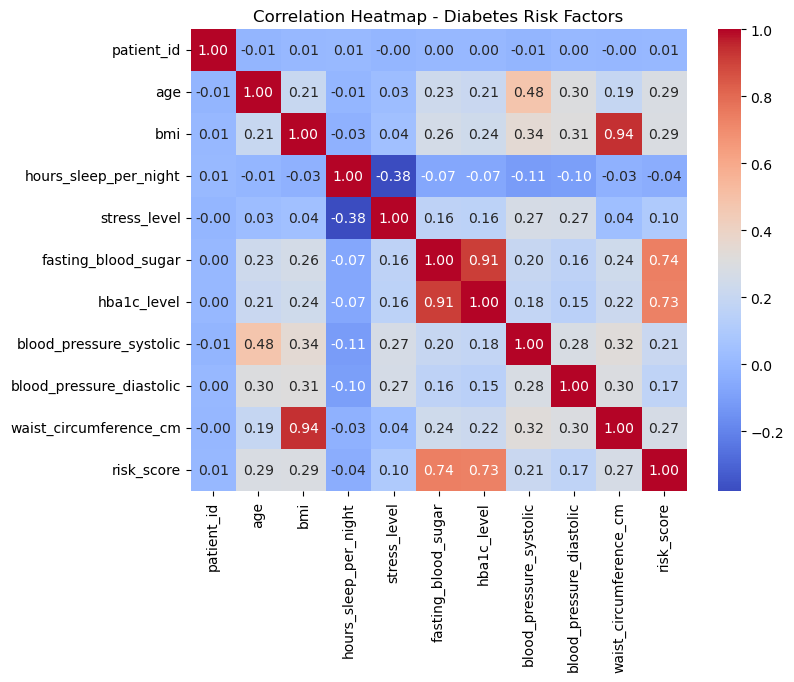

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap - Diabetes Risk Factors")

plt.show()

## Key Findings
- Fasting blood sugar (0.74) and HbA1c (0.73) are by far the strongest 
  predictors of diabetes risk in this dataset — far stronger than age, 
  BMI, or lifestyle factors.
- BMI and waist circumference are nearly redundant (0.94 correlation), 
  as are fasting blood sugar and HbA1c (0.91) — both pairs measure 
  overlapping information.
- Sleep and stress are moderately negatively correlated (-0.38): 
  patients with less sleep report higher stress.